In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
class SalesDataAnalyzer:

    def __init__(self):
        self.data = None
        print()
        print("Sales Data Analyzer Started....")
        print()

    def __del__(self):
        print()
        print("Program Closed...")
        print()
        
    def load_data(self):
        print()
        file_path = input("Enter the path of the dataset (CSV file): ")
        print()
        try:
            self.data = pd.read_csv(file_path)
            print()
            print("Dataset loaded successfully!")
            print()
        except FileNotFoundError:
            print()
            print(f"Error: File '{file_path}' not found. Please try again.")
            print()
        except Exception as e:
                print(f"Error while loading data :{e}")   
            
    def explore_data(self):
        if self.data is None:
            print("Please load the data first !!!")
            print()
            return
            
        while True :
            print()
            print("--- Explore Data ---")
            print()
            print("1. Display the first 5 rows")
            print("2. Display the last 5 rows")
            print("3. Display column names")
            print("4. Display data types")
            print("5. Display basic info")
            print("6.Exit")
            print()

            choice = int(input("Enter your choice:"))
            print()

            match choice:
                case 1:
                    print()
                    print(self.data.head())
                    print()
                case 2:
                    print()
                    print(self.data.tail())
                    print()
                case 3:
                    print()
                    print(self.data.columns.tolist())
                    print()
                case 4:
                    print()
                    print(self.data.dtypes)
                    print()
                case 5:
                    print()
                    print(self.data.info())
                    print()
                case 6:
                    print()
                    print("Exiting....")
                    print()
                    break
                case _:
                    print()
                    print("Invailid choice")
                    print()
                    

    def dataframe_operations(self):
        if self.data is None:
            print("Error: No data loaded.") 
            print()
            return
            
        while True:    
            print()            
            print("--- DataFrame Operations ---")
            print()
            print("1. Convert a column to Numpy Array & Slice")
            print("2. Filter data by Region")
            print("3. Sort data by Sales")
            print("4. Create a Pivot Table")
            print("5.Exit")
            print()
        
            choice = int(input("Enter your choice: "))  
            print()


            match choice:
                case 1:
                    print()
                    col = input(f"Enter column name to convert to Numpy {list(self.data.columns)}: ")
                    print()
                    
                    if col in self.data.columns:
                        numpy_arr = self.data[col].to_numpy()
                        print(f"First 5 elements of Numpy array: {numpy_arr[:5]}")
                        print()
                    else:
                        print("Column not found.")
                        print()

                case 2:
                    print()
                    region = input("Enter Region to filter by (e.g., North, South): ")
                    print()
                    filtered_df = self.data[self.data['Region'].str.lower() == region.lower()]
                    print()
                    display(filtered_df)
                    print()


                case 3:
                    print()
                    sorted_df = self.data.sort_values(by='Sales', ascending=False)
                    print()
                    print("Data sorted by Sales (Descending):")
                    display(sorted_df.head())
                    print()
                    
                        
                case 4:
                   try:
                       pivot = pd.pivot_table(self.data, values='Sales', index='Product', columns='Region', aggfunc='sum')
                       print()
                       display(pivot)
                       print()
                   except Exception as e:
                       print(f"Could not create pivot table: {e}")
                       print()
                       
                case 5:
                     print()
                     print("Exiting....")
                     print()
                     break
                       
                case _:
                    print("Invalid choice.")  
                    print()

    def handle_missing_data(self):
        if self.data is None:
            print("Please load the data first !!!")
            print()
            return
            
        while True:
            print()
            print("--- Handle Missing Data ---")
            print()
            print("1. Display rows with missing values")
            print("2. Fill missing values with mean")
            print("3. Drop rows with missing values")
            print("4. Replace missing values with a specific value")
            print("5.Exit")
            print()

            choice = int(input("Enter your choice:"))
            print()

            match choice:
                case 1:
                    missing_data = self.data[self.data.isnull().any(axis=1)]
                    if missing_data.empty:
                        print()
                        print("NO missing value found in Datasate")
                        print()
                        
                    else:
                        print()
                        print(missing_data)
                        print()
                        
                case 2:
                    numeric_cols = self.data.select_dtypes(include=[np.number]).columns
                    self.data[numeric_cols] = self.data[numeric_cols].fillna(self.data[numeric_cols].mean())
                    print()
                    print("Missing value have been filled with the mean.")
                    print()
                    print("Updated Dataset:")
                    print(self.data)
                    print()
                    
                case 3:
                    self.data.dropna(inplace=True)
                    print()
                    print("Rows containing missing values have been deleted.")
                    print()
                    print("Updated Dataset:")
                    print(self.data)
                    print()
               
                case 4:
                    print()
                    val = input("Enter the value to replace missing data with: ")
                    print()
                    self.data.fillna(val, inplace=True)
                    print(f"Missing values replaced with '{val}'.")
                    print()
                    print("Updated Dataset:")
                    print(self.data)
                    print()
                    
                case 5:
                    print()
                    print("Exiting....")
                    print()
                    break
                    
                case _:
                    print()
                    print("Invailid choice")
                    print()    
                    
    def generate_statistics(self):
        if self.data is None:
            print("Error: No data loaded.")
            print()
            return

        print()
        print("--- Descriptive Statistics ---")
        print()
        display(self.data.describe())
        print()
        print("Aggregate Total Sales:", self.data['Sales'].sum())
        print("Average Profit:", self.data['Profit'].mean())
        print()

        
    def visualize_data(self):
        if self.data is None:
            print("Error: No data loaded.")
            print()
            return
            
        while True:
            print()
            print("--- Data Visualization ---")
            print()
            print("1. Bar Plot (Sales by Product)")
            print("2. Line Plot")
            print("3. Scatter Plot")
            print("4. Pie Chart (Sales by Region)")
            print("5. Histogram")
            print("6. Seaborn Heatmap (Correlation)")
            print("7.Exit")
            print()

            choice = int(input("Enter your choice: "))
            print()
            self.last_fig = plt.figure(figsize=(8, 5))

            match choice:
                case 1:
                    sns.barplot(x= 'Product',y= 'Sales', color = 'purple', edgecolor = 'black',linewidth = 2, data=self.data, estimator = sum,errorbar = None)
                    plt.title('Total Sales by Product')
                    plt.xlabel('--- Product ---')
                    plt.ylabel('--- Sales ----')
                    plt.show()
                    
                case 2:
                      sns.lineplot(x='Month', y='Sales', data=self.data, color = 'red',linewidth = 3, marker = '*')
                      plt.title('Sales Trend over Years')
                      plt.xlabel('--- Month ---')
                      plt.ylabel('--- Sales ---')
                      plt.show()

                case 3:
                    print()
                    x_col = input("Enter x-axis column name (e.g., Sales): ")
                    y_col = input("Enter y-axis column name (e.g., Profit): ")
                    print()
                    print("Generating scatter plot...")
                    print()
                    
                    try:
                       sns.scatterplot(x=x_col, y=y_col, color = 'orange', edgecolor = 'red', s = 100, data=self.data, hue='Region')
                       plt.title(f"Scatter Plot: {x_col} vs {y_col}")
                       plt.show()
                       print("Scatter plot displayed successfully!")
                       print() 
                        
                    except Exception as e:
                      print(f"Error generating plot: {e}")
                      print()



                case 4:
                    region_sales = self.data.groupby('Region')['Sales'].sum()
                    plt.pie(region_sales, labels = region_sales.index, autopct = '%1.1f%%',startangle = 90)
                    plt.title("Sales Distribution by Region")
                    plt.show()

                case 5:
                    col = input("Enter column for Histogram (e.g., Sales): ")
                    try:
                         sns.histplot(self.data[col], kde=True)
                         plt.title(f"Histogram of {col}")
                         plt.show()
                    except Exception as e:
                         print(f"Error: {e}")
                         print()

                case 6:
                    numeric_df = self.data.select_dtypes(include=np.number)
                    sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
                    plt.title("Correlation Heatmap")
                    plt.show()
                
                case 7:
                    print()
                    print("Exiting....")
                    print()
                    break
                    
                case _:
                    print()
                    print("Invailid choice")
                    print()
                    self.last_fig = None
                                 
    def save_visualization(self):
        if self.last_fig is None:
            print("No active visualization to save. Please generate a plot first.")
            print()
            return
            
        print()    
        file_name = input("Enter file name to save the plot (e.g., scatter_plot.png): ")
        print()
        
        try:
            self.last_fig.savefig(file_name, bbox_inches='tight')
            print(f"Visualization saved as {file_name} successfully !!!")
            print()
        except Exception as e:
            print(f"Failed to save image: {e}")
            print()
            self.last_fig = None

   





            


Sales Data Analyzer Started....


========== Data Analysis & Visualization Program ==========

Please select an option:
1. Load Dataset
2. Explore Data
3. Perform DataFrame Operations
4. Handle Missing Data
5. Generate Descriptive Statistics
6. Data Visualization
7. Save Visualization
8. Exit
----------------------------------------------------------




Enter your choice:  1



--- Load Dataset ---



Enter the path of the dataset (CSV file):  sales_data_Q1.csv




Dataset loaded successfully!


========== Data Analysis & Visualization Program ==========

Please select an option:
1. Load Dataset
2. Explore Data
3. Perform DataFrame Operations
4. Handle Missing Data
5. Generate Descriptive Statistics
6. Data Visualization
7. Save Visualization
8. Exit
----------------------------------------------------------



...

,SalesID,Quantity,Discount(%),Sales,Profit
count,79.000000,79.000000,79.000000,79.000000,79.000000
mean,1261.392405,7.861266,10.012917,289348.934204,77195.591177
std,134.824902,4.565030,7.161370,237575.514404,75060.229242
min,1001.000000,1.000000,0.000000,4594.250000,1035.350000
25%,1167.000000,3.500000,5.000000,84376.250000,15948.385000
50%,1260.000000,8.000000,10.000000,249968.000000,58550.920000
75%,1340.000000,12.000000,15.000000,425721.300000,104067.125000
max,1498.000000,15.000000,20.000000,906494.400000,317087.210000



Aggregate Total Sales: 22858565.802083332
Average Profit: 77195.59117721519


========== Data Analysis & Visualization Program ==========

Please select an option:
1. Load Dataset
2. Explore Data
3. Perform DataFrame Operations
4. Handle Missing Data
5. Generate Descriptive Statistics
6. Data Visualization
7. Save Visualization
8. Exit
----------------------------------------------------------




Enter your choice:  6




--- Data Visualization ---

1. Bar Plot (Sales by Product)
2. Line Plot
3. Scatter Plot
4. Pie Chart (Sales by Region)
5. Histogram
6. Seaborn Heatmap (Correlation)
7.Exit



Enter your choice:  1


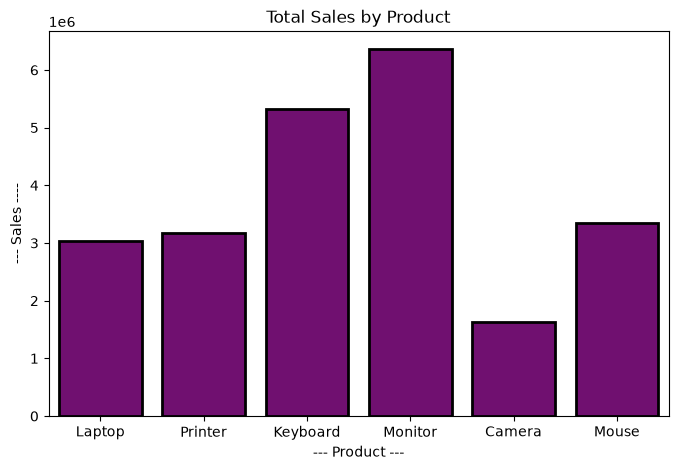


--- Data Visualization ---

1. Bar Plot (Sales by Product)
2. Line Plot
3. Scatter Plot
4. Pie Chart (Sales by Region)
5. Histogram
6. Seaborn Heatmap (Correlation)
7.Exit



Enter your choice:  2


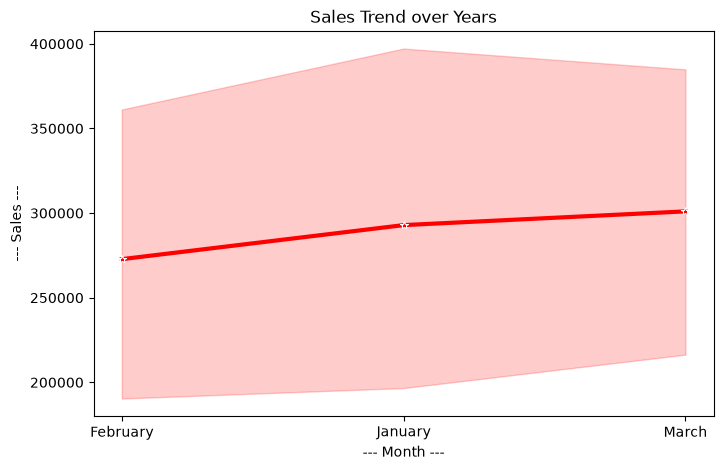


--- Data Visualization ---

1. Bar Plot (Sales by Product)
2. Line Plot
3. Scatter Plot
4. Pie Chart (Sales by Region)
5. Histogram
6. Seaborn Heatmap (Correlation)
7.Exit



Enter your choice:  3


Enter x-axis column name (e.g., Sales):  Sales
Enter y-axis column name (e.g., Profit):  Profit



Generating scatter plot...



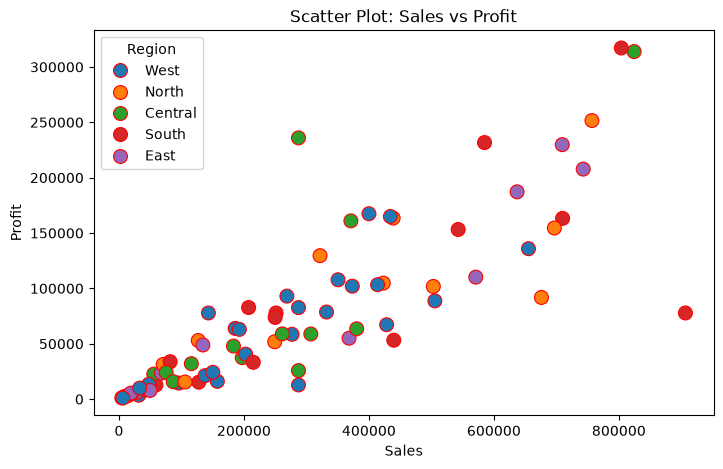

Scatter plot displayed successfully!


--- Data Visualization ---

1. Bar Plot (Sales by Product)
2. Line Plot
3. Scatter Plot
4. Pie Chart (Sales by Region)
5. Histogram
6. Seaborn Heatmap (Correlation)
7.Exit



Enter your choice:  4


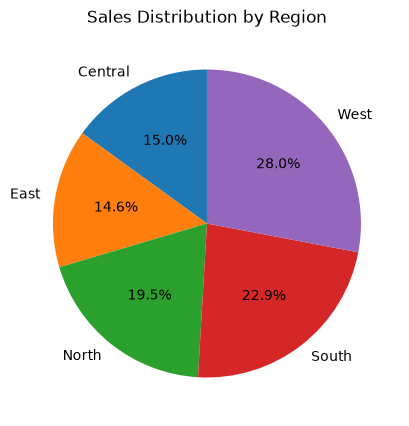


--- Data Visualization ---

1. Bar Plot (Sales by Product)
2. Line Plot
3. Scatter Plot
4. Pie Chart (Sales by Region)
5. Histogram
6. Seaborn Heatmap (Correlation)
7.Exit



Enter your choice:  5


Enter column for Histogram (e.g., Sales):  Sales


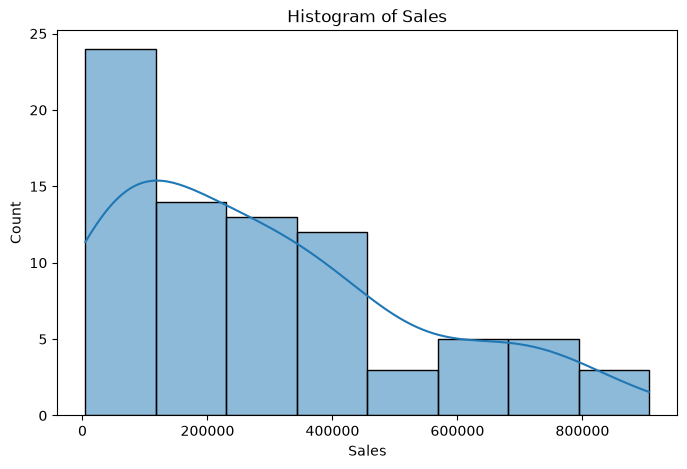


--- Data Visualization ---

1. Bar Plot (Sales by Product)
2. Line Plot
3. Scatter Plot
4. Pie Chart (Sales by Region)
5. Histogram
6. Seaborn Heatmap (Correlation)
7.Exit



Enter your choice:  6


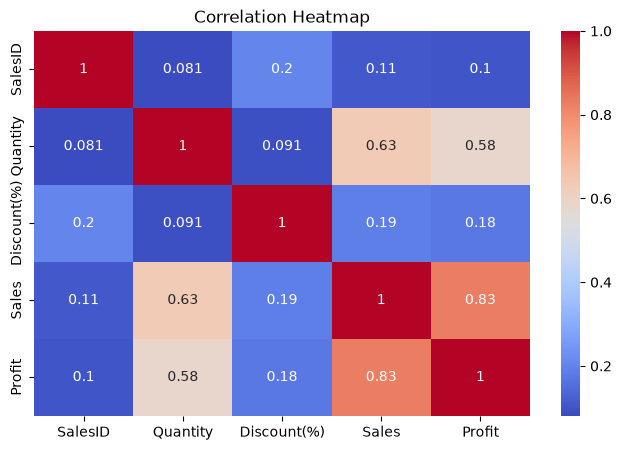


--- Data Visualization ---

1. Bar Plot (Sales by Product)
2. Line Plot
3. Scatter Plot
4. Pie Chart (Sales by Region)
5. Histogram
6. Seaborn Heatmap (Correlation)
7.Exit



Enter your choice:  7




Exiting....


========== Data Analysis & Visualization Program ==========

Please select an option:
1. Load Dataset
2. Explore Data
3. Perform DataFrame Operations
4. Handle Missing Data
5. Generate Descriptive Statistics
6. Data Visualization
7. Save Visualization
8. Exit
----------------------------------------------------------




Enter your choice:  7



--- Save Visualization ---



Enter file name to save the plot (e.g., scatter_plot.png):  Histogram.png



Visualization saved as Histogram.png successfully !!!


========== Data Analysis & Visualization Program ==========

Please select an option:
1. Load Dataset
2. Explore Data
3. Perform DataFrame Operations
4. Handle Missing Data
5. Generate Descriptive Statistics
6. Data Visualization
7. Save Visualization
8. Exit
----------------------------------------------------------




Enter your choice:  8



Exiting the program. Goodbye !!!

Program Closed...



<Figure size 800x500 with 0 Axes>

In [5]:
def main():
        analyzer = SalesDataAnalyzer()


        while True:
            print()
            print("========== Data Analysis & Visualization Program ==========")
            print()
            print("Please select an option:")
            print("1. Load Dataset")
            print("2. Explore Data")
            print("3. Perform DataFrame Operations")
            print("4. Handle Missing Data")
            print("5. Generate Descriptive Statistics")
            print("6. Data Visualization")
            print("7. Save Visualization")
            print("8. Exit")
            print("----------------------------------------------------------")
            print()
        
            main_choice = int(input("\nEnter your choice: "))
            print()
        
            match main_choice:
                case 1:
                   print("--- Load Dataset ---")
                   analyzer.load_data()
                case 2:
                   analyzer.explore_data()
                case 3:
                   analyzer.dataframe_operations()
                case 4:
                   analyzer.handle_missing_data()
                case 5:
                   analyzer.generate_statistics()
                case 6:
                  analyzer.visualize_data()
                case 7:
                   print("--- Save Visualization ---")
                   analyzer.save_visualization()
                case 8:
                   print("Exiting the program. Goodbye !!!")
                   break
                case _:
                   print("Invalid input. Please enter a number between 1 and 8.")


if __name__ == '__main__':
       main()
